# Times Series Analysis On the Data International Airline Passenger From 1940 To 1960

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose


In [5]:
# data fetch from github
df = pd.read_csv("AirPassengers.csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
df.shape

(144, 2)

<Axes: xlabel='Month', ylabel='#Passengers'>

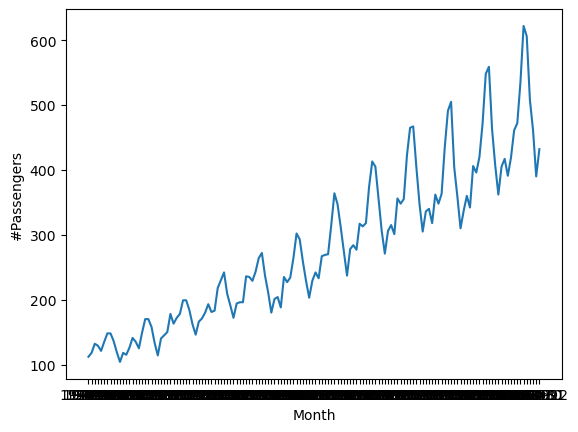

In [7]:
# plot this data to see trends and seasonality with seaborn
sns.lineplot(x="Month", y="#Passengers", data=df)

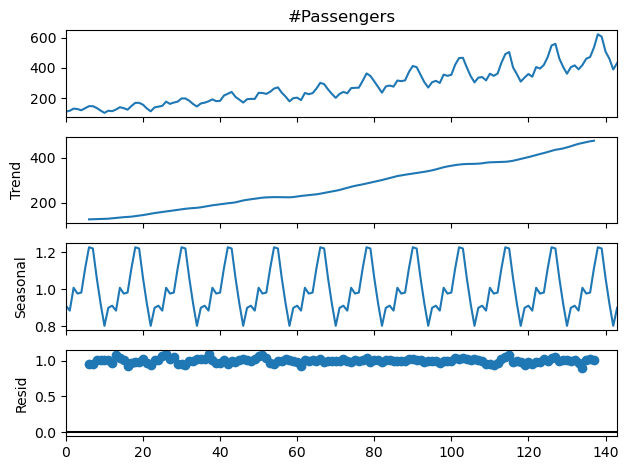

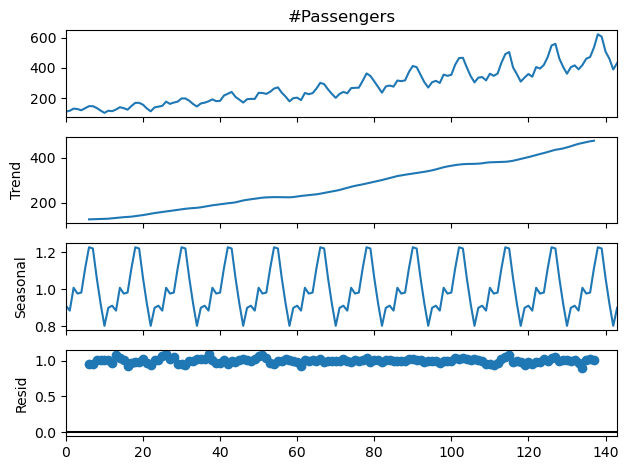

In [8]:
# deompose the data into trand, seansonlity, and residuals
decompose = seasonal_decompose(df['#Passengers'], model="multiplicative", period=12)
decompose.plot()

<Axes: >

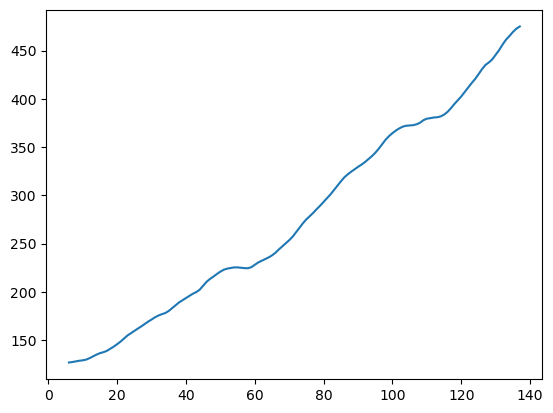

In [10]:
# we can plot separately trand , residuals, and seasonal
decompose.trend.plot()

In [9]:
trend = decompose.trend
seasonal = decompose.seasonal
residual = decompose.resid

In [12]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 61859.3750 - root_mean_squared_error: 248.7155
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 43258.3945 - root_mean_squared_error: 207.9865
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 29151.4023 - root_mean_squared_error: 170.7378
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 18751.9707 - root_mean_squared_error: 136.9378
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 11385.4668 - root_mean_squared_error: 106.7027
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7147.4678 - root_mean_squared_error: 84.5427 
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4829.6172 - root_mean_squared_error: 69.4954
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3837.9109 - root_mean_squared_error: 61.9509
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3442.4697 - root_mean_squared_error: 58.6726
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9m

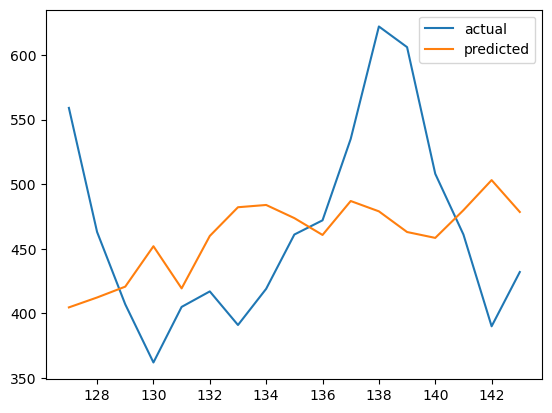

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.metrics import RootMeanSquaredError

# split the data into training and testing sets
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

# define the number of lagged time steps to use as input features
n_lags = 12

# create the input and output data for the neural network
X_train = np.array([train["#Passengers"].values[i:i+n_lags] for i in range(len(train)-n_lags)])
y_train = np.array(train["#Passengers"].values[n_lags:])
X_test = np.array([test["#Passengers"].values[i:i+n_lags] for i in range(len(test)-n_lags)])
y_test = np.array(test["#Passengers"].values[n_lags:])

# create the neural network model
model = Sequential()
model.add(Dense(10, input_dim=n_lags, activation="relu"))
model.add(Dense(1))

# compile the model
model.compile(loss="mean_squared_error", optimizer="adam", metrics=[RootMeanSquaredError()])

# train the neural network model
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1)

# make predictions on the testing set using the trained model
predictions = model.predict(X_test)

# plot the actual and predicted values
plt.plot(test.index[-len(predictions):], test["#Passengers"].values[-len(predictions):], label="actual")
plt.plot(test.index[-len(predictions):], predictions, label="predicted")
plt.legend()
plt.show()